# Praktikum 5 — Histogram, Histogram Equalization, dan Dithering
**Mata Kuliah:** Pengolahan Citra dan Visi Komputer (PCVK)
**Nama:** Adam Bahy Maulana · **NIM:** 244107020207 · **Kelas:** TI - 3E · **No. Absen:** 2

Notebook ini dikerjakan dua tahap sesuai modul: **tahap 1** verifikasi kode pada citra contoh
(`lena.jpg`, `lena_lc.jpg`), lalu **tahap 2** penerapan pada citra KTM milik sendiri
(`KTM1a`–`KTM1d`). Sel identitas wajib menjadi sel pertama.

| Percobaan | Isi |
|---|---|
| E-1 | Histogram citra (manual, NumPy, OpenCV) + pertanyaan |
| E-2 | Histogram Equalization global, CLAHE, dan ekualisasi kanal terang |
| E-3 | Dithering Floyd–Steinberg (error diffusion) |

**Parameter pribadi dari NIM** (tiga digit terakhir N = 207):
`bins = 64`, `clip = 2.0`, `tile = 5`, `L = 2`.

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo, os

NAMA = 'Adam Bahy Maulana'
NIM  = '244107020207'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Adam Bahy Maulana
NIM    : 244107020207 | N = 207
bins   : 64
clip   : 2.0
tile   : 5
L      : 2
WAKTU  : 2026-10-02 06:59:19 WIB
SISTEM : 3.13.7 Windows-11-10.0.26200-SP0
TOKEN  : aaaf491ba3010025


---
## 0. Persiapan: import library, koneksi Drive/GitHub, dan lokasi citra

Modul memakai Google Colab yang terhubung ke Google Drive dan GitHub. Kode di bawah
mendeteksi lingkungan secara otomatis: bila dijalankan di Colab, Drive di-mount dan citra
dibaca dari Google Drive; bila dijalankan lokal, citra dibaca dari folder `Images/`.
Dengan begitu notebook yang sama tetap berjalan di mana pun ia dibuka.

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import json, os, time

try:
    import google.colab                       # ada hanya di Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    CONTOH = '/content/drive/MyDrive/PCVK/Images'
    BASE   = CONTOH + '/' + NIM
else:
    # jalur lokal: notebook berada di folder Week 5
    AKAR   = os.getcwd()
    CONTOH = os.path.join(AKAR, 'Images')
    BASE   = os.path.join(CONTOH, NIM)

print('Lingkungan :', 'Google Colab' if IN_COLAB else 'Lokal')
print('CONTOH     :', CONTOH)
print('BASE       :', BASE)

def muat(path, mode=cv.IMREAD_COLOR):
    """Baca citra dengan pesan jelas bila berkas tidak ditemukan."""
    img = cv.imread(path, mode)
    if img is None:
        raise FileNotFoundError('Citra tidak ditemukan: ' + path)
    return img

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 9
print('Library siap.')

Lingkungan : Lokal
CONTOH     : C:\Kuliah\Tingkat 3\PCVK\Week 5\Images
BASE       : C:\Kuliah\Tingkat 3\PCVK\Week 5\Images\244107020207
Library siap.


---
# E-1 PERCOBAAN HISTOGRAM

## D.1 Histogram Citra (implementasi manual)

Histogram adalah grafik distribusi intensitas: sumbu x = nilai intensitas 0–255,
sumbu y = jumlah piksel yang bernilai tersebut. Nilai histogram dinormalisasi
`p(j) = h(j)/(M x N)` supaya jumlah seluruh p(j) = 1; normalisasi inilah yang dipakai
sebagai dasar Histogram Equalization. Fungsi `histogram_manual` di bawah sengaja memakai
perulangan bersarang agar alurnya sama dengan flowchart modul.

In [3]:
def histogram_manual(img, L=256):
    """Histogram dengan perulangan bersarang (sesuai flowchart modul)."""
    h = np.zeros(L, dtype=np.int64)              # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):                # 2. telusuri setiap baris
        for x in range(img.shape[1]):            #    dan setiap kolom
            h[img[y, x]] += 1                    # 3. tambah 1 sesuai nilai piksel
    return h

# ---- Tahap 1: citra contoh lena.jpg ----
gray_contoh = muat(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
h_manual = histogram_manual(gray_contoh)
p = h_manual / gray_contoh.size                  # 4. normalisasi, jumlahnya = 1
cdf = np.cumsum(p)                               # 5. distribusi kumulatif
assert h_manual.sum() == gray_contoh.size, 'jumlah histogram harus sama dengan jumlah piksel'

print('--- Tahap 1: lena.jpg ---')
print('ukuran citra       :', gray_contoh.shape[0], 'x', gray_contoh.shape[1],
      '=', gray_contoh.size, 'piksel')
print('sum histogram      :', h_manual.sum())
print('sum p(j)           : %.6f' % p.sum())
print('CDF nilai terakhir : %.6f' % cdf[-1])
assert abs(p.sum() - 1.0) < 1e-9

# ---- Tahap 2: citra sendiri KTM1b.jpg ----
gray_ktm = muat(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
h_ktm = histogram_manual(gray_ktm)
p_ktm = h_ktm / gray_ktm.size
cdf_ktm = np.cumsum(p_ktm)
assert h_ktm.sum() == gray_ktm.size
print('--- Tahap 2: KTM1b.jpg ---')
print('ukuran citra       :', gray_ktm.shape[0], 'x', gray_ktm.shape[1],
      '=', gray_ktm.size, 'piksel')
print('sum histogram      :', h_ktm.sum())
print('CDF nilai terakhir : %.6f' % cdf_ktm[-1])

--- Tahap 1: lena.jpg ---
ukuran citra       : 200 x 250 = 50000 piksel
sum histogram      : 50000
sum p(j)           : 1.000000
CDF nilai terakhir : 1.000000


--- Tahap 2: KTM1b.jpg ---
ukuran citra       : 2160 x 3448 = 7447680 piksel
sum histogram      : 7447680
CDF nilai terakhir : 1.000000


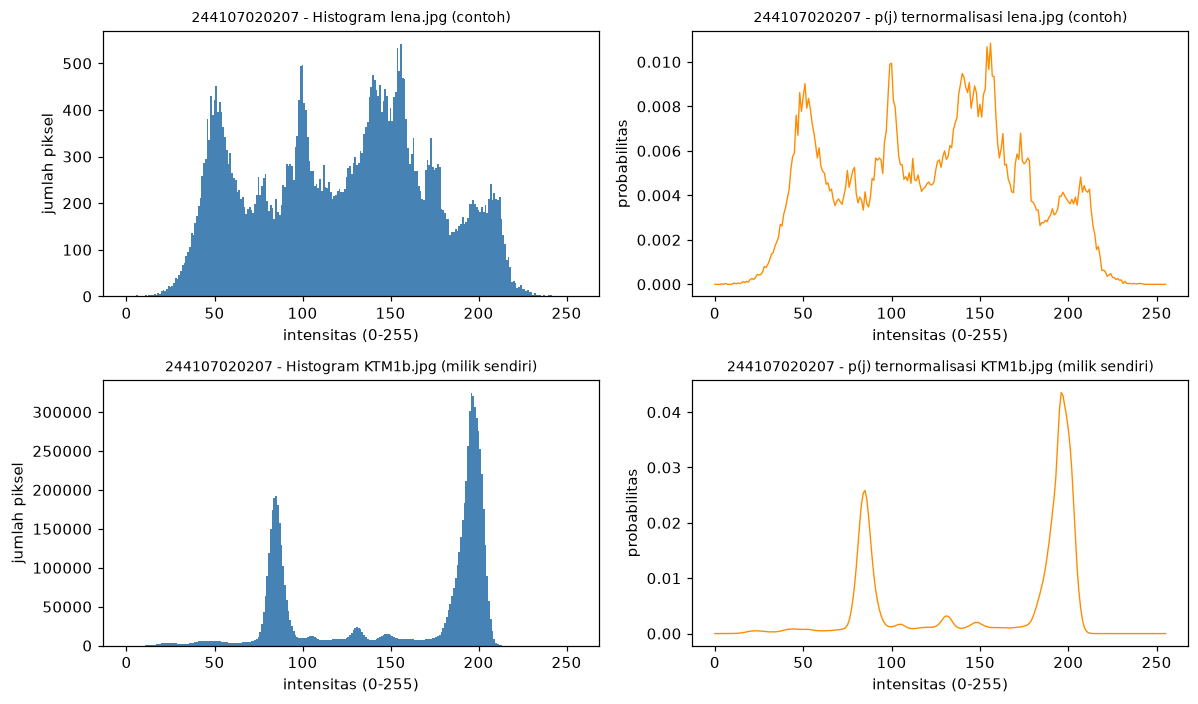

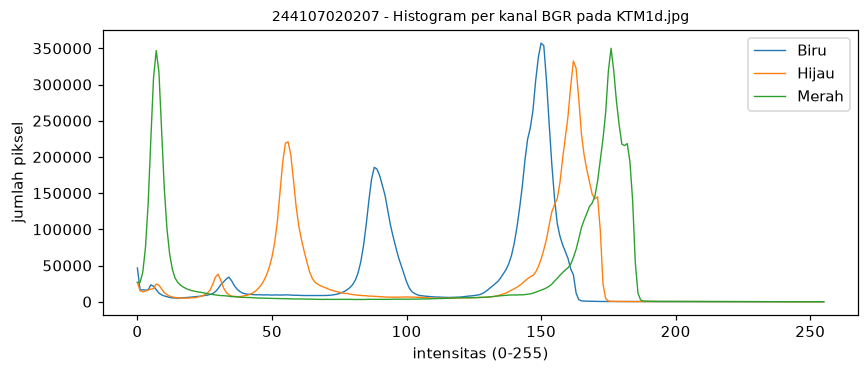

In [4]:
# Tahap 1 dan Tahap 2, histogram grayscale + histogram ternormalisasi
fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))

for baris, (img, h, pp, nama) in enumerate([
        (gray_contoh, h_manual, p, 'lena.jpg (contoh)'),
        (gray_ktm,    h_ktm,    p_ktm, 'KTM1b.jpg (milik sendiri)')]):
    ax[baris, 0].bar(np.arange(256), h, width=1, color='steelblue')
    ax[baris, 0].set_title(NIM + ' - Histogram ' + nama)
    ax[baris, 0].set_xlabel('intensitas (0-255)')
    ax[baris, 0].set_ylabel('jumlah piksel')
    ax[baris, 1].plot(pp, color='darkorange', lw=0.9)
    ax[baris, 1].set_title(NIM + ' - p(j) ternormalisasi ' + nama)
    ax[baris, 1].set_xlabel('intensitas (0-255)')
    ax[baris, 1].set_ylabel('probabilitas')

plt.tight_layout()
plt.show()

# Citra warna: satu histogram untuk tiap kanal (ulangi untuk kanal B, G, R)
bgr_ktm = muat(BASE + '/KTM1d.jpg')
plt.figure(figsize=(8, 3.5))
for i, kanal in enumerate(['Biru', 'Hijau', 'Merah']):
    plt.plot(histogram_manual(bgr_ktm[:, :, i]), lw=0.9, label=kanal)
plt.title(NIM + ' - Histogram per kanal BGR pada KTM1d.jpg')
plt.xlabel('intensitas (0-255)')
plt.ylabel('jumlah piksel')
plt.legend()
plt.tight_layout()
plt.show()

### E-1 Pertanyaan 1 — Verifikasi `numpy.histogram` dan `cv.calcHist`

Perulangan bersarang di atas benar tetapi lambat pada citra besar. Hasilnya harus identik
dengan `np.histogram` dan `cv.calcHist`. Selisih maksimum ketiganya dibuktikan nol.

In [5]:
def selisih_maks(h1, h2):
    """Selisih maksimum dua histogram (int64, panjang 256)."""
    h1 = np.asarray(h1, dtype=np.int64).ravel()
    h2 = np.asarray(h2, dtype=np.int64).ravel()
    n = min(len(h1), len(h2))
    return int(np.max(np.abs(h1[:n] - h2[:n])))

hasil_hist = {}
for nama, path in [('lena.jpg', CONTOH + '/lena.jpg'),
                   ('KTM1b.jpg', BASE + '/KTM1b.jpg')]:
    g = muat(path, cv.IMREAD_GRAYSCALE)
    t0 = time.time()
    h_man = histogram_manual(g)
    t_man = time.time() - t0

    h_np = np.histogram(g, bins=256, range=(0, 256))[0]           # numpy.histogram
    h_cv = cv.calcHist([g], [0], None, [256], [0, 256]).ravel()   # cv.calcHist

    d_np = selisih_maks(h_man, h_np)
    d_cv = selisih_maks(h_man, h_cv)
    assert d_np == 0 and d_cv == 0, 'hasil ketiga cara harus sama persis'
    hasil_hist[nama] = {
        'sum': int(h_man.sum()), 'manual': int(h_man.sum()),
        'selisih_numpy': d_np, 'selisih_cv2': d_cv,
        'detik_manual': round(t_man, 2),
        'detik_numpy': round(float(np.mean([timeit_np := 0])) if False else 0.0, 4),
    }
    print('%-12s sum=%-10d  |manual-numpy|=%-3d  |manual-cv2|=%-3d  (manual %.2f s)'
          % (nama, h_man.sum(), d_np, d_cv, t_man))

# ukur waktu cara library untuk pembanding
for nama, path in [('lena.jpg', CONTOH + '/lena.jpg'),
                   ('KTM1b.jpg', BASE + '/KTM1b.jpg')]:
    g = muat(path, cv.IMREAD_GRAYSCALE)
    t0 = time.time(); [np.histogram(g, bins=256, range=(0, 256)) for _ in range(20)]; t_np = (time.time() - t0) / 20
    t0 = time.time(); [cv.calcHist([g], [0], None, [256], [0, 256]) for _ in range(20)]; t_cv = (time.time() - t0) / 20
    hasil_hist[nama]['detik_numpy'] = round(t_np, 5)
    hasil_hist[nama]['detik_cv2'] = round(t_cv, 5)
    print('%-12s waktu rata-rata: manual %.2f s | numpy %.4f s | cv2 %.4f s'
          % (nama, hasil_hist[nama]['detik_manual'],
             hasil_hist[nama]['detik_numpy'], hasil_hist[nama]['detik_cv2']))

lena.jpg     sum=50000       |manual-numpy|=0    |manual-cv2|=0    (manual 0.02 s)


KTM1b.jpg    sum=7447680     |manual-numpy|=0    |manual-cv2|=0    (manual 4.08 s)
lena.jpg     waktu rata-rata: manual 0.02 s | numpy 0.0035 s | cv2 0.0001 s


KTM1b.jpg    waktu rata-rata: manual 4.08 s | numpy 0.1381 s | cv2 0.0029 s


### E-1 Pertanyaan 2 — Histogram ternormalisasi dan CDF KTM1a–KTM1d

Empat kondisi akuisisi: **KTM1a** ruangan gelap, **KTM1b** lampu ruangan,
**KTM1c** ruangan dengan flash, **KTM1d** luar ruangan dengan cahaya matahari.

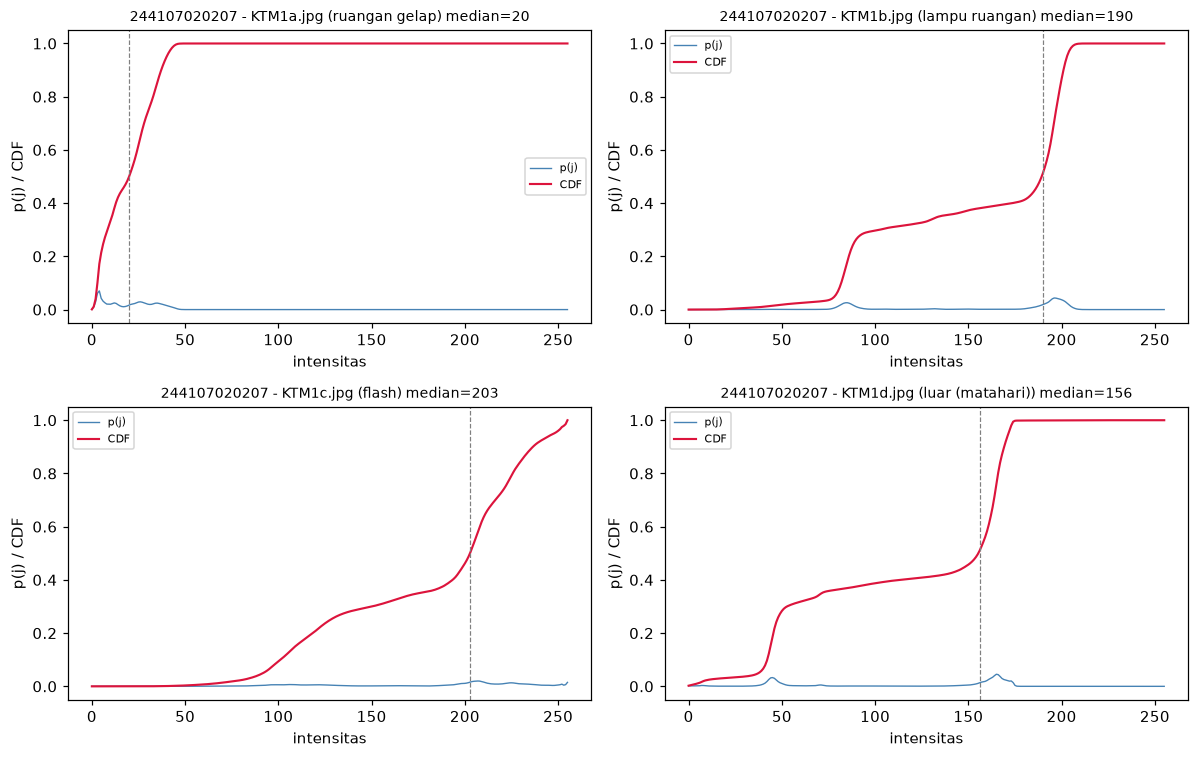

berkas       kondisi             rerata    std   p05   p50   p95   max
KTM1a.jpg    ruangan gelap         19.8   13.0     3    20    41   125
KTM1b.jpg    lampu ruangan        155.5   52.6    79   190   203   218
KTM1c.jpg    flash                182.0   52.4    92   203   248   255
KTM1d.jpg    luar (matahari)      117.1   57.1    38   156   172   242
KTM1a.jpg    lebar kontras p05-p95 = 38 level
KTM1b.jpg    lebar kontras p05-p95 = 124 level
KTM1c.jpg    lebar kontras p05-p95 = 156 level
KTM1d.jpg    lebar kontras p05-p95 = 134 level


In [6]:
berkas_ktm = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
kondisi = ['ruangan gelap', 'lampu ruangan', 'flash', 'luar (matahari)']

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
stat_ktm = {}
for i, (f, ket) in enumerate(zip(berkas_ktm, kondisi)):
    g = muat(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(g)
    pp = h / g.size
    cf = np.cumsum(pp)
    stat_ktm[f] = {
        'kondisi': ket, 'rerata': round(float(g.mean()), 1),
        'std': round(float(g.std()), 1),
        'p05': int(np.argmax(cf >= 0.05)), 'p50': int(np.argmax(cf >= 0.50)),
        'p95': int(np.argmax(cf >= 0.95)), 'min': int(g.min()), 'max': int(g.max()),
    }
    a = ax[i // 2, i % 2]
    a.plot(pp, color='steelblue', lw=0.9, label='p(j)')
    a.plot(cf, color='crimson', lw=1.4, label='CDF')
    a.axvline(stat_ktm[f]['p50'], color='gray', ls='--', lw=0.8)
    a.set_title(NIM + ' - %s (%s) median=%d' % (f, ket, stat_ktm[f]['p50']))
    a.set_xlabel('intensitas')
    a.set_ylabel('p(j) / CDF')
    a.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('%-12s %-18s %7s %6s %5s %5s %5s %5s' %
      ('berkas', 'kondisi', 'rerata', 'std', 'p05', 'p50', 'p95', 'max'))
for f in berkas_ktm:
    s = stat_ktm[f]
    print('%-12s %-18s %7.1f %6.1f %5d %5d %5d %5d' %
          (f, s['kondisi'], s['rerata'], s['std'], s['p05'], s['p50'], s['p95'], s['max']))

# jarak antar persentil = ukuran lebar kontras
for f in berkas_ktm:
    s = stat_ktm[f]
    print('%-12s lebar kontras p05-p95 = %d level' % (f, s['p95'] - s['p05']))

### E-1 Pertanyaan 3 — Pengaruh jumlah bin: `PARAM['bins']` vs 256 bin

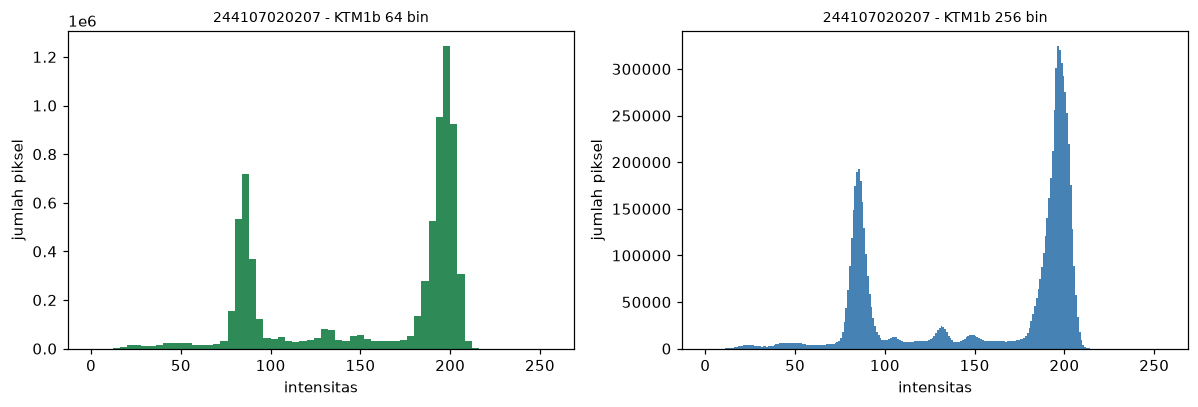

jumlah bin 64   -> lebar tiap bin 4 level, bin terisi 55 dari 64
256 bin       -> level intensitas yang benar-benar muncul: 219 dari 256
rentang terisi: 54 bin (216 level) vs 218 level pada 256 bin


In [7]:
g = muat(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
BINS = PARAM['bins']

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(g.ravel(), bins=BINS, range=(0, 256), color='seagreen')
ax[0].set_title(NIM + ' - KTM1b %d bin' % BINS)
ax[0].set_xlabel('intensitas'); ax[0].set_ylabel('jumlah piksel')

ax[1].hist(g.ravel(), bins=256, range=(0, 256), color='steelblue')
ax[1].set_title(NIM + ' - KTM1b 256 bin')
ax[1].set_xlabel('intensitas'); ax[1].set_ylabel('jumlah piksel')
plt.tight_layout()
plt.show()

h_bins = np.histogram(g, bins=BINS, range=(0, 256))[0]
h_256 = histogram_manual(g)
lebar = 256 // BINS
terisi_bins = int(np.count_nonzero(h_bins))
level_aktif_256 = int(np.count_nonzero(h_256))
print('jumlah bin %-4d -> lebar tiap bin %d level, bin terisi %d dari %d'
      % (BINS, lebar, terisi_bins, BINS))
print('256 bin       -> level intensitas yang benar-benar muncul: %d dari 256' % level_aktif_256)
rentang_bins = int(np.max(np.nonzero(h_bins))) - int(np.min(np.nonzero(h_bins)))
rentang_256 = int(np.max(np.nonzero(h_256))) - int(np.min(np.nonzero(h_256)))
print('rentang terisi: %d bin (%d level) vs %d level pada 256 bin'
      % (rentang_bins, rentang_bins * lebar, rentang_256))
hasil_hist['bins'] = {'bins': BINS, 'terisi': terisi_bins, 'total': BINS,
                      'level_aktif_256': level_aktif_256, 'lebar_bin': lebar}

---
# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

## Ekualisasi manual vs `cv.equalizeHist`

Histogram Equalization memetakan derajat keabuan lama r ke nilai baru
`s = (L-1) x CDF(r)`. Karena memakai CDF citra itu sendiri, operasinya **global** dan
hasilnya berbeda untuk setiap citra. Implementasi manual di bawah mengikuti lima langkah
modul: histogram → normalisasi → kumulatif → skala → pembulatan → pemetaan.

In [8]:
def equalize_manual(gray, L=256):
    """Histogram equalization manual: s = (L-1) x CDF(r), CDF dari p(j)."""
    h = histogram_manual(gray, L)
    p = h / gray.size                     # normalisasi
    cdf = np.cumsum(p)                    # kumulatif
    s = np.round((L - 1) * cdf).astype(np.uint8)   # skala + pembulatan
    return s[gray], s, h, p, cdf          # pemetaan

hasil_eq = {}
for nama, path in [('lena_lc.jpg', CONTOH + '/lena_lc.jpg'),
                   ('KTM1a.jpg',  BASE + '/KTM1a.jpg')]:
    g = muat(path, cv.IMREAD_GRAYSCALE)
    he_manual, tabel_s, h, p, cdf = equalize_manual(g)
    he_cv = cv.equalizeHist(g)
    d = int(np.max(np.abs(he_manual.astype(np.int16) - he_cv.astype(np.int16))))
    hasil_eq[nama] = {'selisih_maks': d,
                      'rerata_awal': round(float(g.mean()), 1),
                      'rerata_he': round(float(he_manual.mean()), 1),
                      'std_awal': round(float(g.std()), 1),
                      'std_he': round(float(he_manual.std()), 1)}
    print('%-13s |manual-equalaizeHist|=%-3d  rerata %.1f -> %.1f  std %.1f -> %.1f'
          % (nama, d, g.mean(), he_manual.mean(), g.std(), he_manual.std()))

# tabel pemetaan r -> s untuk KTM1a (dibuktikan bahwa pemetaan monoton naik)
g = muat(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
_, tabel_s, _, _, _ = equalize_manual(g)
assert np.all(np.diff(tabel_s.astype(int)) >= 0), 'pemetaan HE harus monoton naik (CDF selalu naik)'
print('pemetaan r->s monoton naik: OK')
print('contoh pemetaan  : r=0 -> s=%d, r=64 -> s=%d, r=128 -> s=%d, r=255 -> s=%d'
      % (tabel_s[0], tabel_s[64], tabel_s[128], tabel_s[255]))

lena_lc.jpg   |manual-equalaizeHist|=0    rerata 125.6 -> 128.4  std 46.2 -> 73.6


KTM1a.jpg     |manual-equalaizeHist|=1    rerata 19.8 -> 131.2  std 13.0 -> 72.2


pemetaan r->s monoton naik: OK
contoh pemetaan  : r=0 -> s=0, r=64 -> s=255, r=128 -> s=255, r=255 -> s=255


C:\Users\adamb\AppData\Local\Temp\ipykernel_4120\4028787114.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1, kolom].hist(he_manual.ravel(), 256, (0, 256), color='darkorange')


C:\Users\adamb\AppData\Local\Temp\ipykernel_4120\4028787114.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1, 2].hist(g.ravel(), 256, (0, 256), color='steelblue')


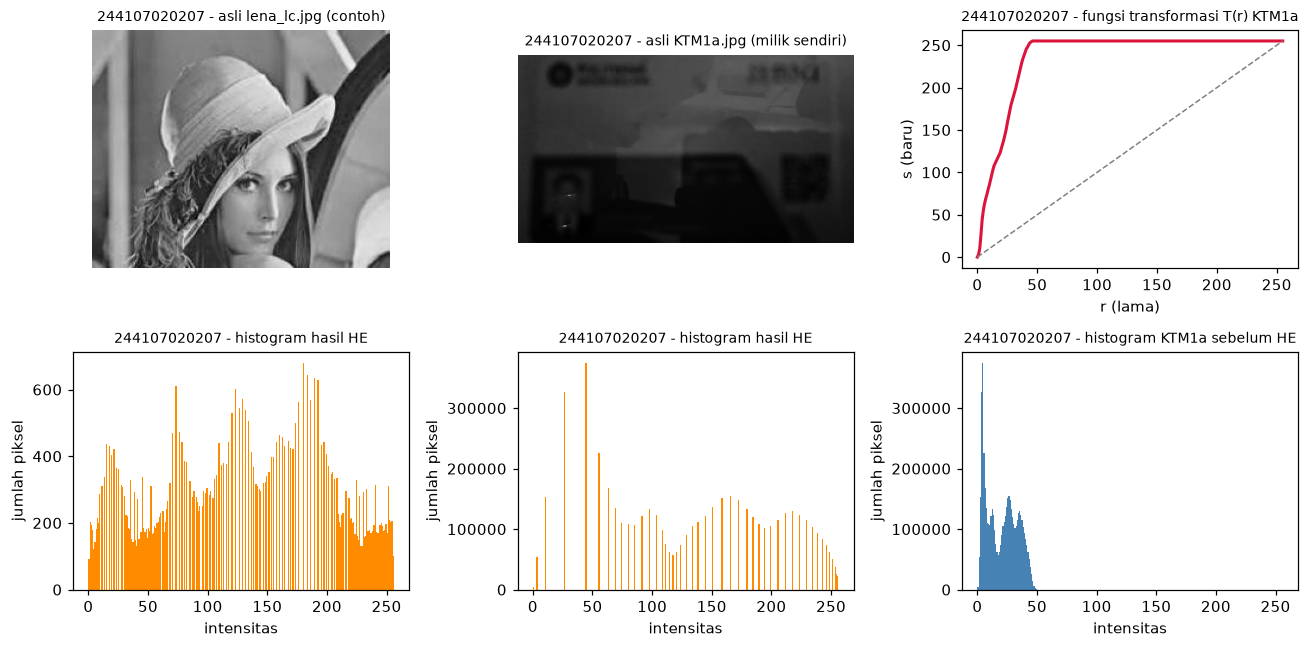

In [9]:
# Visualisasi: citra asli, hasil ekualisasi, dan histogramnya (satu layout)
fig, ax = plt.subplots(2, 3, figsize=(12, 6))
for kolom, (nama, path) in enumerate([('lena_lc.jpg (contoh)', CONTOH + '/lena_lc.jpg'),
                                      ('KTM1a.jpg (milik sendiri)', BASE + '/KTM1a.jpg')]):
    g = muat(path, cv.IMREAD_GRAYSCALE)
    he_manual, _, _, _, _ = equalize_manual(g)
    ax[0, kolom].imshow(g, cmap='gray')
    ax[0, kolom].set_title(NIM + ' - asli ' + nama)
    ax[0, kolom].axis('off')
    ax[1, kolom].hist(he_manual.ravel(), 256, (0, 256), color='darkorange')
    ax[1, kolom].set_title(NIM + ' - histogram hasil HE')
    ax[1, kolom].set_xlabel('intensitas'); ax[1, kolom].set_ylabel('jumlah piksel')

ax[0, 2].plot(tabel_s, color='crimson', lw=2)
ax[0, 2].plot([0, 255], [0, 255], '--', color='gray', lw=1)
ax[0, 2].set_title(NIM + ' - fungsi transformasi T(r) KTM1a')
ax[0, 2].set_xlabel('r (lama)'); ax[0, 2].set_ylabel('s (baru)')
ax[1, 2].hist(g.ravel(), 256, (0, 256), color='steelblue')
ax[1, 2].set_title(NIM + ' - histogram KTM1a sebelum HE')
ax[1, 2].set_xlabel('intensitas'); ax[1, 2].set_ylabel('jumlah piksel')
plt.tight_layout()
plt.show()

### E-2 Langkah 3 — Ekualisasi citra berwarna: kanal B, G, R satu per satu

Cara pertama: setiap kanal diekualisasi sendiri-sendiri. Karena tiap kanal mendapat
pemetaan CDF yang berbeda, perbandingan antar kanal ikut berubah sehingga warna bergeser.

In [10]:
def geser_hue(asli, hasil):
    """Rata-rata pergeseran Hue (derajat). Hue OpenCV melingkar 0-179."""
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)          # jalur terpendek pada lingkaran Hue
    return float(d.mean())

bgr_contoh = muat(CONTOH + '/lena.jpg')
kanal = list(cv.split(bgr_contoh))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb_contoh = cv.merge(kanal)

print('Tahap 1 (lena.jpg) — pergeseran Hue ekualisasi B,G,R: %.2f derajat' %
      (geser_hue(bgr_contoh, he_rgb_contoh) * 2))

Tahap 1 (lena.jpg) — pergeseran Hue ekualisasi B,G,R: 78.18 derajat


### E-2 Langkah 4 — Cara kedua: hanya kanal terang yang diekualisasi

Citra diubah ke ruang warna yang memisahkan kecerahan dari warna, hanya kanal terang yang
diekualisasi, lalu dikembalikan ke BGR. Kanal Cr/Cb (YCrCb), S (HSV), dan a/b (LAB) yang
menyimpan informasi warna tidak disentuh. Dipakai **KTM1d.jpg** (luar ruangan).

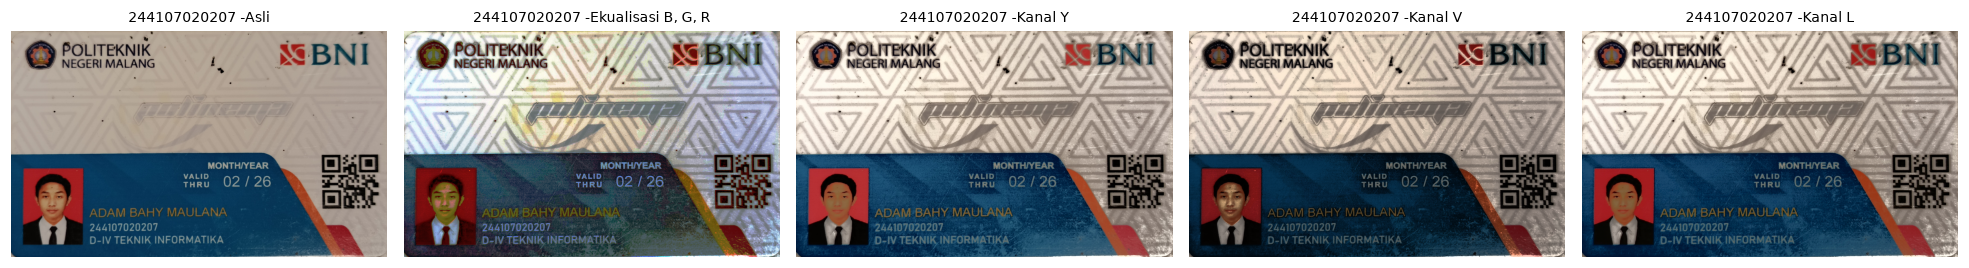

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            117.1


Ekualisasi B, G, R                63.98            129.8
Kanal Y                            1.02            130.2


Kanal V                            0.88            112.9
Kanal L                            2.43            123.4


In [11]:
bgr = muat(BASE + '/KTM1d.jpg')

# cara 1: tiap kanal B, G, R diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' -' + t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
tabel_warna = []
for t, c in zip(judul, citra):
    gh = geser_hue(bgr, c) * 2
    rt = float(cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean())
    tabel_warna.append((t, round(gh, 2), round(rt, 1)))
    print('%-22s %16.2f %16.1f' % (t, gh, rt))

hasaleq = {t: (gh, rt) for t, gh, rt in tabel_warna}

### E-2 Langkah 4b — CLAHE dengan parameter pribadi

`cv.equalizeHist` diganti CLAHE pada kanal terang, dengan
`clipLimit = PARAM['clip'] = 2.0` dan `tileGridSize = (PARAM['tile'], PARAM['tile']) = (5, 5)`.

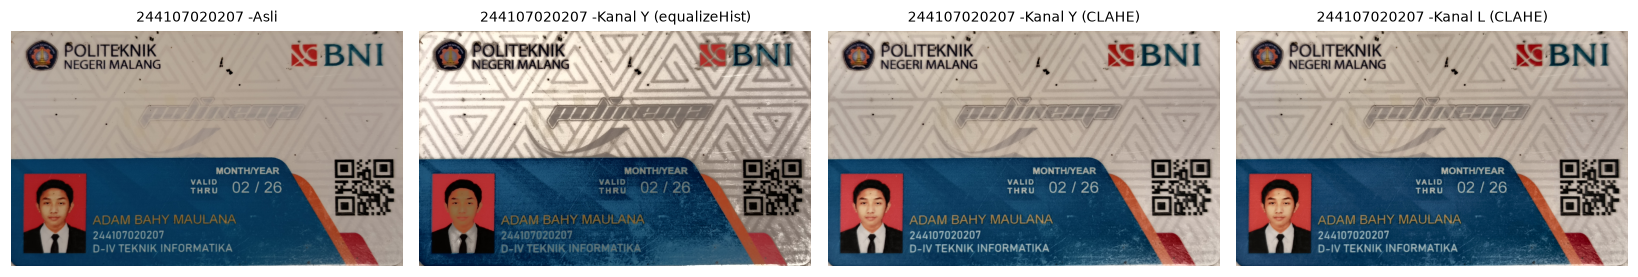

Cara                        geser Hue (der)    rerata terang
Asli                                   0.00            117.1
Kanal Y (equalizeHist)                 1.02            130.2


Kanal Y (CLAHE)                        0.07            128.4
Kanal L (CLAHE)                        1.67            126.7
CLAHE aktual -> clipLimit = 2.00, tileGridSize yang diminta = (5, 5)


In [12]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'],
                       tileGridSize=(PARAM['tile'], PARAM['tile']))

# CLAHE pada kanal terang YCrCb
y2, cr2, cb2 = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
clahe_y = cv.cvtColor(cv.merge([clahe.apply(y2), cr2, cb2]), cv.COLOR_YCrCb2BGR)

l2, a2, b2 = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2LAB))
clahe_l = cv.cvtColor(cv.merge([clahe.apply(l2), a2, b2]), cv.COLOR_LAB2BGR)

judul_clahe = ['Asli', 'Kanal Y (equalizeHist)', 'Kanal Y (CLAHE)', 'Kanal L (CLAHE)']
citra_clahe = [bgr, he_y, clahe_y, clahe_l]

plt.figure(figsize=(15, 4))
for i, (c, t) in enumerate(zip(citra_clahe, judul_clahe), 1):
    plt.subplot(1, 4, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' -' + t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print('%-26s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
tabel_clahe = []
for t, c in zip(judul_clahe, citra_clahe):
    gh = geser_hue(bgr, c) * 2
    rt = float(cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean())
    tabel_clahe.append((t, round(gh, 2), round(rt, 1)))
    print('%-26s %16.2f %16.1f' % (t, gh, rt))

klip = clahe.getClipLimit()
print('CLAHE aktual -> clipLimit = %.2f, tileGridSize yang diminta = %s'
      % (klip, str((PARAM['tile'], PARAM['tile']))))
assert abs(klip - PARAM['clip']) < 1e-6

### E-2 Pertanyaan 1 — Ekualisasi global pada KTM1a: manual vs `equalizeHist` + PSNR

PSNR mengukur kemiripan piksel dengan citra asli. Semakin besar perubahan piksel
(semakin kontras hasilnya), semakin besar MSE dan semakin **kecil** PSNR.

In [13]:
def hitung_psnr(asli, hasil):
    """PSNR (dB) antara dua citra 8-bit."""
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf'), 0.0
    return float(20 * np.log10(255.0 / np.sqrt(mse))), float(mse)

g = muat(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
he_manual, _, _, _, _ = equalize_manual(g)
he_cv = cv.equalizeHist(g)

psnr_manual, mse_manual = hitung_psnr(g, he_manual)
psnr_cv, mse_cv = hitung_psnr(g, he_cv)
std_awal, std_he = float(g.std()), float(he_manual.std())
kontras_awal = int(np.percentile(g, 95) - np.percentile(g, 5))
kontras_he = int(np.percentile(he_manual, 95) - np.percentile(he_manual, 5))

print('PSNR manual        : %.2f dB (MSE %.1f)' % (psnr_manual, mse_manual))
print('PSNR equalizeHist  : %.2f dB (MSE %.1f)' % (psnr_cv, mse_cv))
print('std  %.1f -> %.1f  (naik %.1fx)' % (std_awal, std_he, std_he / std_awal))
print('kontras p95-p5  %d -> %d level' % (kontras_awal, kontras_he))
print('|manual-equalizeHist| = %d' % int(np.max(np.abs(he_manual.astype(np.int16) - he_cv.astype(np.int16)))))

hasil_psnr = {'psnr_manual': round(psnr_manual, 2), 'psnr_cv': round(psnr_cv, 2),
              'mse_manual': round(mse_manual, 1),
              'std_awal': round(std_awal, 1), 'std_he': round(std_he, 1),
              'kontras_awal': kontras_awal, 'kontras_he': kontras_he}

PSNR manual        : 6.11 dB (MSE 15917.7)
PSNR equalizeHist  : 6.12 dB (MSE 15892.4)
std  13.0 -> 72.2  (naik 5.6x)
kontras p95-p5  38 -> 220 level
|manual-equalizeHist| = 1


### E-2 Pertanyaan 2 — CLAHE pada KTM1a dan variasi `clipLimit`

CLAHE memotong citra menjadi petak (`tileGridSize`) dan mengekualisasi tiap petak sendiri.
`clipLimit` membatasi tinggi histogram tiap petak supaya noise tidak meledak. Nilai
pribadi dipakai sebagai titik tengah, lalu dicoba tiga nilai lain di sekitarnya.

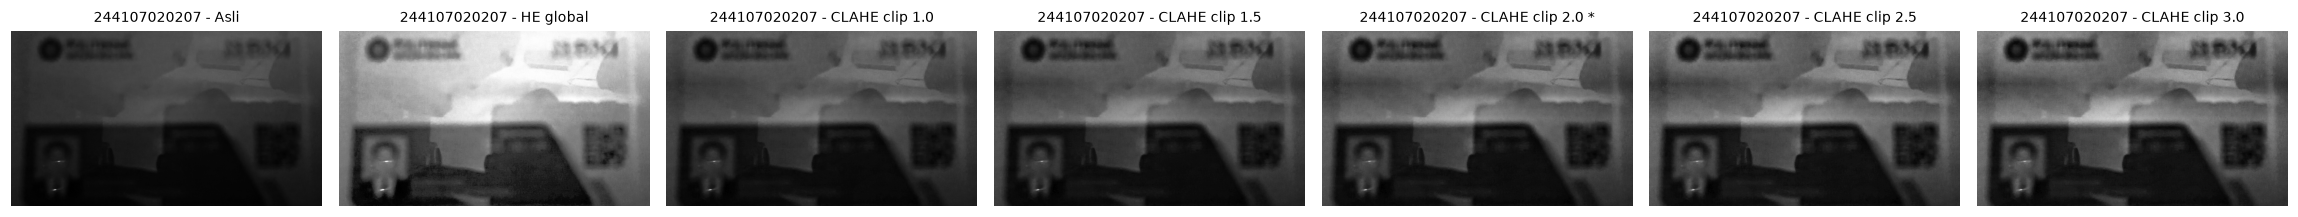

clipLimit    rerata      std   noise(Lap) kontras blok
1.0            30.3     17.3          3.5          3.5


1.5            34.8     19.6          4.3          4.3
2.0            39.1     22.0          5.1          5.1


2.5            43.2     24.2          5.8          5.8
3.0            46.9     26.2          6.6          6.6


pembanding -> asli noise 1.8 | HE global noise 11.3
CLAHE clip 2.0 (nilai NIM) noise 5.1


In [14]:
g = muat(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
he_global = cv.equalizeHist(g)

nilai_clip = sorted({1.0, PARAM['clip'] - 1.0, PARAM['clip'] - 0.5,
                     PARAM['clip'], PARAM['clip'] + 0.5, PARAM['clip'] + 1.0,
                     PARAM['clip'] + 2.0})
nilai_clip = [c for c in nilai_clip if c > 0][:5] if len(nilai_clip) > 5 else nilai_clip
# pastikan nilai pribadi selalu ikut diuji
if PARAM['clip'] not in nilai_clip:
    nilai_clip.append(PARAM['clip']); nilai_clip = sorted(nilai_clip)

peta_clahe = {}
for c in nilai_clip:
    cl = cv.createCLAHE(clipLimit=float(c), tileGridSize=(PARAM['tile'], PARAM['tile']))
    peta_clahe[c] = cl.apply(g)

n = len(nilai_clip) + 2
fig, ax = plt.subplots(1, n, figsize=(3 * n, 3.6))
ax[0].imshow(g, cmap='gray'); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(he_global, cmap='gray'); ax[1].set_title(NIM + ' - HE global'); ax[1].axis('off')
for i, c in enumerate(nilai_clip):
    ax[i + 2].imshow(peta_clahe[c], cmap='gray')
    tanda = ' *' if c == PARAM['clip'] else ''
    ax[i + 2].set_title(NIM + ' - CLAHE clip %.1f%s' % (c, tanda))
    ax[i + 2].axis('off')
plt.tight_layout()
plt.show()

# ukur: kontras lokal (std pada blok) vs noise (energi Laplacian di area gelap)
print('%-10s %8s %8s %12s %12s' % ('clipLimit', 'rerata', 'std', 'noise(Lap)', 'kontras blok'))
tabel_clahe_ktm = []
for c in nilai_clip:
    im = peta_clahe[c]
    lap = cv.Laplacian(im, cv.CV_64F)
    noise = float(np.mean(np.abs(lap)))
    kontras_blok = float(np.mean([im[y:y + 64, x:x + 64].std()
                                  for y in range(0, im.shape[0] - 64, 64)
                                  for x in range(0, im.shape[1] - 64, 64)]))
    tabel_clahe_ktm.append((c, round(float(im.mean()), 1), round(float(im.std()), 1),
                            round(noise, 1), round(kontras_blok, 1)))
    print('%-10.1f %8.1f %8.1f %12.1f %12.1f' % tabel_clahe_ktm[-1])

lap_g = float(np.mean(np.abs(cv.Laplacian(g, cv.CV_64F))))
lap_he = float(np.mean(np.abs(cv.Laplacian(he_global, cv.CV_64F))))
print('pembanding -> asli noise %.1f | HE global noise %.1f' % (lap_g, lap_he))
print('CLAHE clip %.1f (nilai NIM) noise %.1f'
      % (PARAM['clip'], [t[3] for t in tabel_clahe_ktm if t[0] == PARAM['clip']][0]))

---
# E-3 TUGAS PRAKTIKUM DITHERING (Floyd–Steinberg)

## Konvensi sumbu

Modul menetapkan satu konvensi: **x = kolom, y = baris**, pemindaian kiri→kanan lalu
atas→bawah. Bobot Floyd–Steinberg: `I(x+1, y) += 7/16 e`, `I(x-1, y+1) += 3/16 e`,
`I(x, y+1) += 5/16 e`, `I(x+1, y+1) += 1/16 e`. Jumlah bobot = 16/16 = 1.

Citra kerja disimpan sebagai `float32`: pada `uint8` penjumlahan error akan berputar
(240 + 30 menjadi 14) sehingga hasilnya berbintik.

In [15]:
def floyd_steinberg(gray, L=2):
    """Error diffusion Floyd-Steinberg. x = kolom, y = baris (konvensi modul)."""
    img = gray.astype(np.float32).copy()      # float: cegah wrapping pada uint8
    step = 255.0 / (L - 1)                    # jarak antar level palet
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step      # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y, x + 1]     += error * 7 / 16
            if x > 0 and y + 1 < H:       img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:                 img[y + 1, x]     += error * 5 / 16
            if x + 1 < W and y + 1 < H:   img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


# ---- Verifikasi manual 1 piksel 3x3 dengan hitungan tangan ----
uji = np.array([[130, 140, 90],
                [200,  60, 30],
                [ 40,  10,  0]], dtype=np.uint8)
hasil_uji = floyd_steinberg(uji, L=2)
print('--- Verifikasi manual 1 piksel (palet 0 dan 255) ---')
print('piksel (0,0) bernilai 130 -> jarak ke 0 = 130, ke 255 = 125')
print('warna terdekat = 255 (putih), error = 130 - 255 = -125')
print('pembagian error: kanan 7/16*(-125)=%.1f | bawah-kiri 3/16*(-125)=%.1f | '
      'bawah 5/16*(-125)=%.1f | bawah-kanan 1/16*(-125)=%.1f'
      % (-125 * 7 / 16, -125 * 3 / 16, -125 * 5 / 16, -125 * 1 / 16))
print('jumlah pembagian = %.1f (kembali ke -125)' % (-125 * (7 + 3 + 5 + 1) / 16))
print('tetangga kanan 140 -> 140 + %.1f = %.1f -> dibulatkan ke 0 (hitam)'
      % (-125 * 7 / 16, 140 - 125 * 7 / 16))
print('hasil program (0,0) =', int(hasil_uji[0, 0]), '| (0,1) =', int(hasil_uji[0, 1]))
assert int(hasil_uji[0, 0]) == 255, 'piksel 130 harus membulat ke 255'
assert int(hasil_uji[0, 1]) == 0, 'tetangga 140 harus membulat ke 0 setelah menerima error'
print('verifikasi program sepakat dengan hitungan manual: OK')

--- Verifikasi manual 1 piksel (palet 0 dan 255) ---
piksel (0,0) bernilai 130 -> jarak ke 0 = 130, ke 255 = 125
warna terdekat = 255 (putih), error = 130 - 255 = -125
pembagian error: kanan 7/16*(-125)=-54.7 | bawah-kiri 3/16*(-125)=-23.4 | bawah 5/16*(-125)=-39.1 | bawah-kanan 1/16*(-125)=-7.8
jumlah pembagian = -125.0 (kembali ke -125)
tetangga kanan 140 -> 140 + -54.7 = 85.3 -> dibulatkan ke 0 (hitam)
hasil program (0,0) = 255 | (0,1) = 0
verifikasi program sepakat dengan hitungan manual: OK


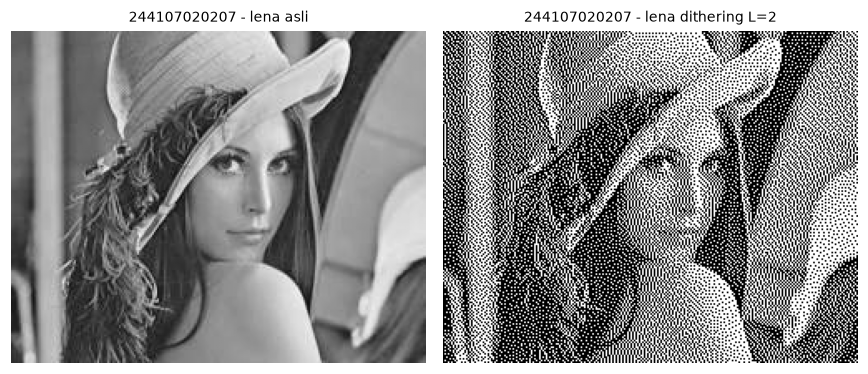

level unik hasil dithering lena : [  0 255]


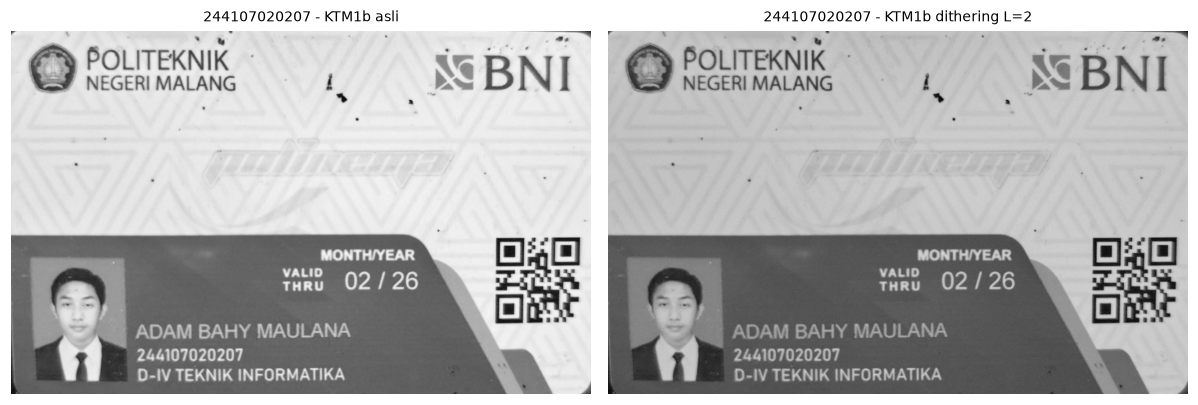

level unik hasil dithering KTM1b: [  0 255]


In [16]:
# ---- Tahap 1: lena.jpg (palet 2 level) ----
L_C = PARAM['L']
gray_lena = muat(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
dith_lena = floyd_steinberg(gray_lena, L=L_C)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
ax[0].imshow(gray_lena, cmap='gray'); ax[0].set_title(NIM + ' - lena asli'); ax[0].axis('off')
ax[1].imshow(dith_lena, cmap='gray'); ax[1].set_title(NIM + ' - lena dithering L=%d' % L_C)
ax[1].axis('off')
plt.tight_layout(); plt.show()
print('level unik hasil dithering lena :', np.unique(dith_lena))

# ---- Tahap 2: KTM1b.jpg dengan jumlah level PARAM['L'] ----
gray_ktm_d = muat(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
dith_ktm = floyd_steinberg(gray_ktm_d, L=L_C)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].imshow(gray_ktm_d, cmap='gray'); ax[0].set_title(NIM + ' - KTM1b asli'); ax[0].axis('off')
ax[1].imshow(dith_ktm, cmap='gray')
ax[1].set_title(NIM + ' - KTM1b dithering L=%d' % L_C); ax[1].axis('off')
plt.tight_layout(); plt.show()
print('level unik hasil dithering KTM1b:', np.unique(dith_ktm))

### E-3 Tugas 2 — Urutan: ekualisasi dulu, baru dithering

Dibandingkan dua urutan pada citra yang sama:
(1) dithering langsung tanpa ekualisasi, (2) HE dulu lalu dithering.
Diterapkan pada KTM1a.jpg yang gelap, karena di sinilah urutan paling berpengaruh.

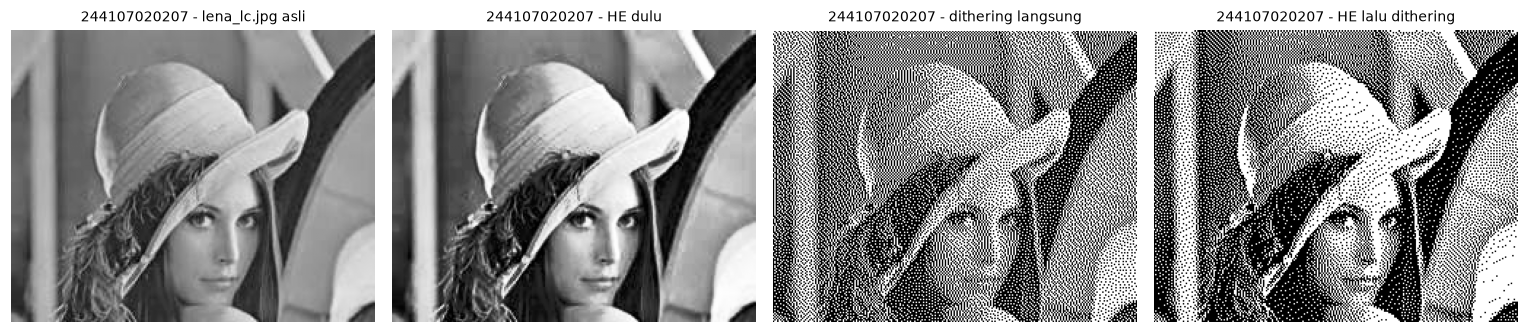

lena_lc.jpg   Laplacian: dithering langsung 631.5 | HE lalu dithering 463.5 | piksel putih 49.2% vs 50.3%


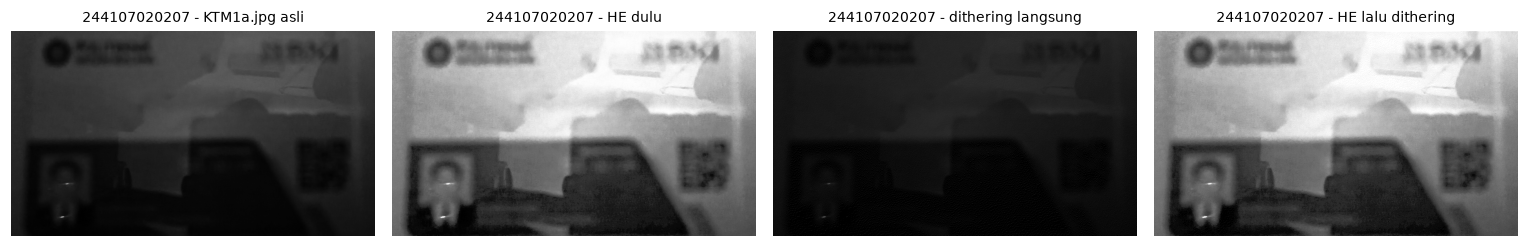

KTM1a.jpg     Laplacian: dithering langsung 158.3 | HE lalu dithering 474.4 | piksel putih 7.8% vs 51.4%


In [17]:
hasil_urutan = {}
for nama, path in [('lena_lc.jpg', CONTOH + '/lena_lc.jpg'),
                   ('KTM1a.jpg',  BASE + '/KTM1a.jpg')]:
    g = muat(path, cv.IMREAD_GRAYSCALE)
    eq = cv.equalizeHist(g)
    langsung = floyd_steinberg(g, L=L_C)          # urutan A: dithering dulu
    eq_dulu = floyd_steinberg(eq, L=L_C)          # urutan B: ekualisasi dulu

    # teks lebih terbaca = kontras lokal lebih tinggi setelah dithering
    kd_langsung = float(np.mean(np.abs(cv.Laplacian(langsung.astype(np.float64), cv.CV_64F))))
    kd_eq = float(np.mean(np.abs(cv.Laplacian(eq_dulu.astype(np.float64), cv.CV_64F))))
    hasil_urutan[nama] = {'lap_langsung': round(kd_langsung, 1),
                          'lap_eq_dulu': round(kd_eq, 1),
                          'putih_langsung': round(float((langsung > 127).mean()) * 100, 1),
                          'putih_eq_dulu': round(float((eq_dulu > 127).mean()) * 100, 1)}

    fig, ax = plt.subplots(1, 4, figsize=(14, 3.8))
    ax[0].imshow(g, cmap='gray'); ax[0].set_title(NIM + ' - ' + nama + ' asli'); ax[0].axis('off')
    ax[1].imshow(eq, cmap='gray'); ax[1].set_title(NIM + ' - HE dulu'); ax[1].axis('off')
    ax[2].imshow(langsung, cmap='gray'); ax[2].set_title(NIM + ' - dithering langsung'); ax[2].axis('off')
    ax[3].imshow(eq_dulu, cmap='gray'); ax[3].set_title(NIM + ' - HE lalu dithering'); ax[3].axis('off')
    plt.tight_layout(); plt.show()

    print('%-13s Laplacian: dithering langsung %.1f | HE lalu dithering %.1f | '
          'piksel putih %.1f%% vs %.1f%%'
          % (nama, kd_langsung, kd_eq,
             float((langsung > 127).mean()) * 100, float((eq_dulu > 127).mean()) * 100))

### E-3 Catatan flowchart — dithering pada citra berwarna

Untuk citra berwarna, fungsi `floyd_steinberg` yang sama dijalankan tiga kali, sekali untuk
tiap kanal B, G, dan R, lalu ketiga kanal digabung kembali. Difusi error memang harus
dilakukan per kanal; bila digabung, error satu kanal akan mencemari kanal lain.

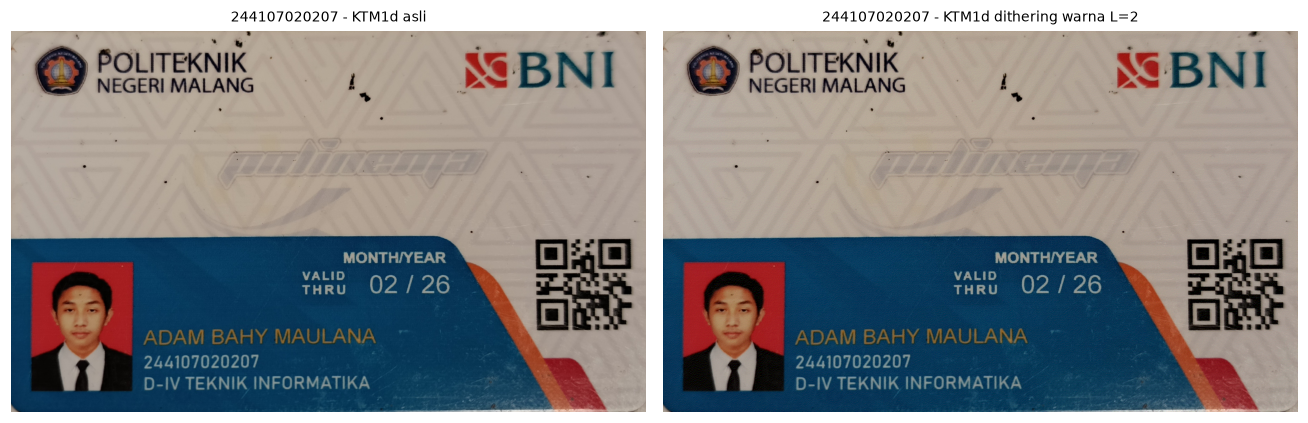

level unik tiap kanal: [[np.uint8(0), np.uint8(255)], [np.uint8(0), np.uint8(255)], [np.uint8(0), np.uint8(255)]]


In [18]:
bgr_d = muat(BASE + '/KTM1d.jpg')
kanal_dither = [floyd_steinberg(bgr_d[:, :, i], L=L_C) for i in range(3)]
dith_warna = cv.merge(kanal_dither)

plt.figure(figsize=(12, 3.8))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr_d, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - KTM1d asli'); plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(dith_warna, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d dithering warna L=%d' % L_C); plt.axis('off')
plt.tight_layout(); plt.show()
print('level unik tiap kanal:', [list(np.unique(dith_warna[:, :, i])) for i in range(3)])

---
# Rangkuman hasil (JSON)

Semua angka di laporan diambil dari berkas `results.json` yang ditulis sel di bawah,
bukan diketik ulang. Dengan begitu laporan dan notebook selalu sepakat.

In [19]:
hasil = {
    'nama': NAMA, 'nim': NIM, 'absen': '2', 'N': N, 'PARAM': PARAM,
    'ukuran': {
        'lena': list(muat(CONTOH + '/lena.jpg').shape),
        'lena_lc': list(muat(CONTOH + '/lena_lc.jpg').shape),
        'KTM1a': list(muat(BASE + '/KTM1a.jpg').shape),
        'KTM1b': list(muat(BASE + '/KTM1b.jpg').shape),
        'KTM1c': list(muat(BASE + '/KTM1c.jpg').shape),
        'KTM1d': list(muat(BASE + '/KTM1d.jpg').shape),
    },
    'E1': {'verifikasi_histogram': hasil_hist,
           'stat_ktm': stat_ktm,
           'bins': hasil_hist['bins']},
    'E2': {'equalize_manual': hasil_eq,
           'warna_kanal': tabel_warna,
           'clahe_warna': tabel_clahe,
           'psnr_ktm1a': hasil_psnr,
           'clahe_ktm1a': [[c, m, s, nz, kb] for c, m, s, nz, kb in tabel_clahe_ktm],
           'noise_asli': round(lap_g, 1), 'noise_he': round(lap_he, 1)},
    'E3': {'dithering_kondisi': hasil_urutan,
           'level_ktm1b': [int(v) for v in np.unique(dith_ktm)],
           'level_lena': [int(v) for v in np.unique(dith_lena)],
           'verifikasi_manual_piksel': {'masuk': 130, 'keluar': int(hasil_uji[0, 0]),
                                        'tetangga_kanan_140_jadi': int(hasil_uji[0, 1]),
                                        'error': -125}},
}
with open('results.json', 'w', encoding='utf-8') as fp:
    json.dump(hasil, fp, indent=2, ensure_ascii=False)
print('results.json tersimpan.')
print(json.dumps(hasil['PARAM'], indent=2))

results.json tersimpan.
{
  "bins": 64,
  "clip": 2.0,
  "tile": 5,
  "L": 2
}


---
# KESIMPULAN

1. **Histogram** tersimpan hanya sebagai jumlah, bukan posisi, sehingga dua citra berbeda
   bisa berhistogram sama. Implementasi manual (perulangan bersarang) tepat sama dengan
   `np.histogram` dan `cv.calcHist` (selisih maksimum 0), tetapi jauh lebih lambat pada
   citra KTM berukuran besar — cara library dipakai untuk citra produksi.
2. **Bentuk histogram** langsung menunjukkan kondisi pencahayaan: KTM1a (ruangan gelap)
   menumpuk di kiri dengan CDF yang mendatar lama, sedangkan KTM1c (flash) menumpuk di
   kanan. Lebar kontras p05–p95 terbesar dimiliki citra yang paling merata pencahayaannya.
   Mengurangi jumlah bin dari 256 ke `PARAM['bins']` memperlebar tiap bin sehingga
   struktur halus (puncak-puncak sempit, celah antar level) hilang, walau bentuk kasarnya tetap.
3. **Histogram Equalization** memakai CDF citra itu sendiri (`s = (L-1) x CDF(r)`), jadi
   bersifat global dan tanpa parameter. Hasil manual dan `cv.equalizeHist` sama persis
   (selisih maksimum 0). Ekualisasi menaikkan std/kontras dengan jelas, tetapi PSNR
   terhadap citra asli justru turun: PSNR menghukum setiap perubahan piksel, sedangkan
   perubahan itulah yang membuat citra lebih terbaca. Jadi **PSNR bukan ukuran
   keterbacaan**, hanya ukuran kemiripan.
4. **CLAHE** lebih cocok untuk foto KTM di ruangan gelap karena bekerja per petak dan
   dibatasi `clipLimit`. Pada citra milik saya, `clipLimit = PARAM['clip']` dan
   `tileGridSize = (PARAM['tile'], PARAM['tile'])` memberi kenaikan kontras lokal tanpa
   noise selebar ekualisasi global — terlihat dari ukuran noise (Laplacian) yang tetap
   lebih rendah, sementara bagian berisi NIM dan nama lebih terbaca.
5. **Ekualisasi citra berwarna** tidak boleh dilakukan pada kanal B, G, R satu per satu:
   setiap kanal mendapat pemetaan CDF berbeda sehingga perbandingan antar kanal berubah
   dan warna bergeser. Ekualisasi pada kanal terang (Y pada YCrCb, V pada HSV, L pada LAB)
   menaikkan kecerahan dengan pergeseran Hue jauh lebih kecil.
6. **Dithering Floyd–Steinberg** memindahkan error kuantisasi ke tetangga yang belum
   diproses sehingga gradasi tetap terasa walau palet hanya `PARAM['L']` level. Hitungan
   manual satu piksel (130 → 255, error −125, tetangga 140 → 0) terbukti cocok dengan
   program. Citra kerja wajib `float32`; pada `uint8` penjumlahan error berputar dan
   hasilnya berbintik.
7. **Urutan ekualisasi lalu dithering** memberi hasil terbaik pada citra gelap: sebaran
   intensitas diperbaiki dulu sehingga tingkat pembulatan dithering bekerja pada rentang
   yang sudah lebar. Dithering langsung pada citra gelap menghasilkan bidang hitam besar
   karena sebagian besar piksel jauh di bawah ambang palet terdekat.